<a href="https://colab.research.google.com/github/Amal1703/-Satellite_Imagery_Segmentation_U-Net_Transformers/blob/main/Satellite_Imagery_U_Net_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Satellite Imagery Unet et transformes


In [1]:
!pip install patchify

In [2]:
!pip uninstall jax jaxlib -y

Found existing installation: jax 0.11.1
Uninstalling jax-0.11.1:
  Successfully uninstalled jax-0.11.1
Found existing installation: jaxlib 0.11.1
Uninstalling jaxlib-0.11.1:
  Successfully uninstalled jaxlib-0.11.1


In [1]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 768.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 138.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 101.9 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [1]:
import os
import requests
import zipfile

import cv2
from PIL import Image
import numpy as np
from patchify import patchify

import glob
import json
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import random

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Dropout

In [3]:
# 1. Définir l'URL directe du fichier ZIP
url = "https://github.com/Amal1703/-Satellite_Imagery_Segmentation_U-Net_Transformers/raw/main/Semantic_segmentation_dataset.zip"
zip_path = "/content/Semantic_segmentation_dataset.zip"
extract_path = "/content/Semantic_segmentation_dataset"

# 2. Télécharger le fichier
print("📥 Téléchargement du fichier ZIP...")
response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(zip_path, 'wb') as f:
        f.write(response.content)
    print("✅ Téléchargement terminé !")
else:
    print(f"❌ Erreur de téléchargement : {response.status_code}")
    raise Exception("Impossible de télécharger le fichier.")

# 3. Décompresser le fichier
print("📦 Décompression du fichier ZIP...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"✅ Décompression terminée dans : {extract_path}")

# 4. Nettoyer le fichier ZIP (optionnel)
os.remove(zip_path)
print("🧹 Fichier ZIP nettoyé.")

📥 Téléchargement du fichier ZIP...
✅ Téléchargement terminé !
📦 Décompression du fichier ZIP...
✅ Décompression terminée dans : /content/Semantic_segmentation_dataset
🧹 Fichier ZIP nettoyé.


In [2]:
%pwd

'/content'

In [3]:
dataset_root_folder = "Semantic_segmentation_dataset/Semantic_segmentation_dataset"

In [4]:
image_patch_size = 256

In [5]:
image_dataset = []
mask_dataset = []


# Détection automatique du nombre de tiles (dossiers "Tile X")
tile_folders = glob.glob(f'{dataset_root_folder}/Tile *')
num_tiles = len(tile_folders)


for image_type in ['images' , 'masks']:

  #1. verfi type des images et des masques

  if image_type == 'images':
    image_extension = 'jpg'

  elif image_type == 'masks': # Ce qu'il ne faut JAMAIS utiliser JPEG/JPG — à éviter absolument pour des masques, car la compression avec perte change les valeurs de pixels
     image_extension = 'png'  # PNG est format le plus courant et recommandé car Compression sans perte contrairement au JPEG/JPG

  else:
    print(f"⚠️ Type inconnu : {image_type}")  # ← Lève une erreur


  for tile_id in range(1, num_tiles + 1):

    # Détection automatique du nombre d'images dans ce tile
    image_folder = f'{dataset_root_folder}/Tile {tile_id}/{image_type}'
    image_files = glob.glob(f'{image_folder}/image_part_*.{image_extension}')
    num_images = len(image_files)

    for image_id in range(1, num_images + 1):

      image_path = f'{image_folder}/image_part_00{image_id}.{image_extension}'

      # cv2.imread ← OpenCV lit en BGR (Bleu-Vert-Rouge)
      image = cv2.imread(image_path, 1)

      if image is not None:

         # Conversion BGR → RGB nécessaire pour les DEUX types :
        # - images : car cv2 charge en BGR, mais matplotlib/PyTorch/TensorFlow attendent du RGB
        # - masks : uniquement si tes masks sont en couleur (RGB par classe, ex: Cityscapes)
        #   Si tes masks sont en niveaux de gris (1 canal = ID de classe), CETTE LIGNE EST INUTILE
        if image_type == 'images':
             image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        elif image_type == 'masks':
                # Vérifie d'abord si tes masks sont en couleur ou en niveaux de gris
                if len(image.shape) == 3 and image.shape[2] == 3:
                    # masks en couleur (une couleur RGB par classe) → conversion nécessaire
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                else:
                    # masks en niveaux de gris (un ID par classe) → pas de conversion
                    pass


        #print(image.shape)
        # Détecte si l'image est en couleur (3 canaux) ou en niveaux de gris (2D)
        is_grayscale = len(image.shape) == 2

        # Redimensionnement image pour que les dimensions soient des multiples de image_patch_size
        size_x = (image.shape[1]//image_patch_size)*image_patch_size
        size_y = (image.shape[0]//image_patch_size)*image_patch_size

        # Conversion en image PIL
        image = Image.fromarray(image)

        image = image.crop((0,0, size_x, size_y)) # requli coin inf sup
        #ou Padding au lieu crop
        #print(image.size[0],image.size[1])
        image = np.array(image)

        # Découpage en patches selon le nombre de canaux, patchify() fonctionne avec des tableaux numpy
        if is_grayscale:
            patched_images = patchify(image, (image_patch_size, image_patch_size), step=image_patch_size)
        else:
            patched_images = patchify(image, (image_patch_size, image_patch_size, 3), step=image_patch_size)

        #print(patched_images.shape) # exple pour Image de (512, 1280, 3) avec patch_size = 256
                                     # patched_images.shape:  (2, 5, 256, 256, 3) = (nombre_patches_y, nombre_patches_x, largeur du patch, hauteur du patch, nombre de canaux)


        for i in range(patched_images.shape[0]): # nombre_patches_y
          for j in range(patched_images.shape[1]): # nombre_patches_x
            if image_type == 'images':
              # Extraire le patch
              individual_patched_image = patched_images[i,j,:,:] # (256, 256, 3)
              individual_patched_image = individual_patched_image[0]
              image_dataset.append(individual_patched_image)

            elif image_type == 'masks':
              individual_patched_mask = patched_images[i,j,:,:]
              individual_patched_mask = individual_patched_mask[0]
              mask_dataset.append(individual_patched_mask)

      else:
          print(f"⚠️ Image introuvable : {image_path}")  # ← Lève une erreur


In [6]:
individual_patched_image.shape, individual_patched_mask.shape

((256, 256, 3), (256, 256, 3))

In [7]:
image_dataset = np.array(image_dataset)
mask_dataset = np.array(mask_dataset)

In [8]:
image_dataset.shape, mask_dataset.shape # (Nombre total de patches dans le dataset, largeur du patch, hauteur du patch, nombre de canaux)

((945, 256, 256, 3), (945, 256, 256, 3))

In [9]:
print(len(image_dataset))
print(len(mask_dataset))

945
945


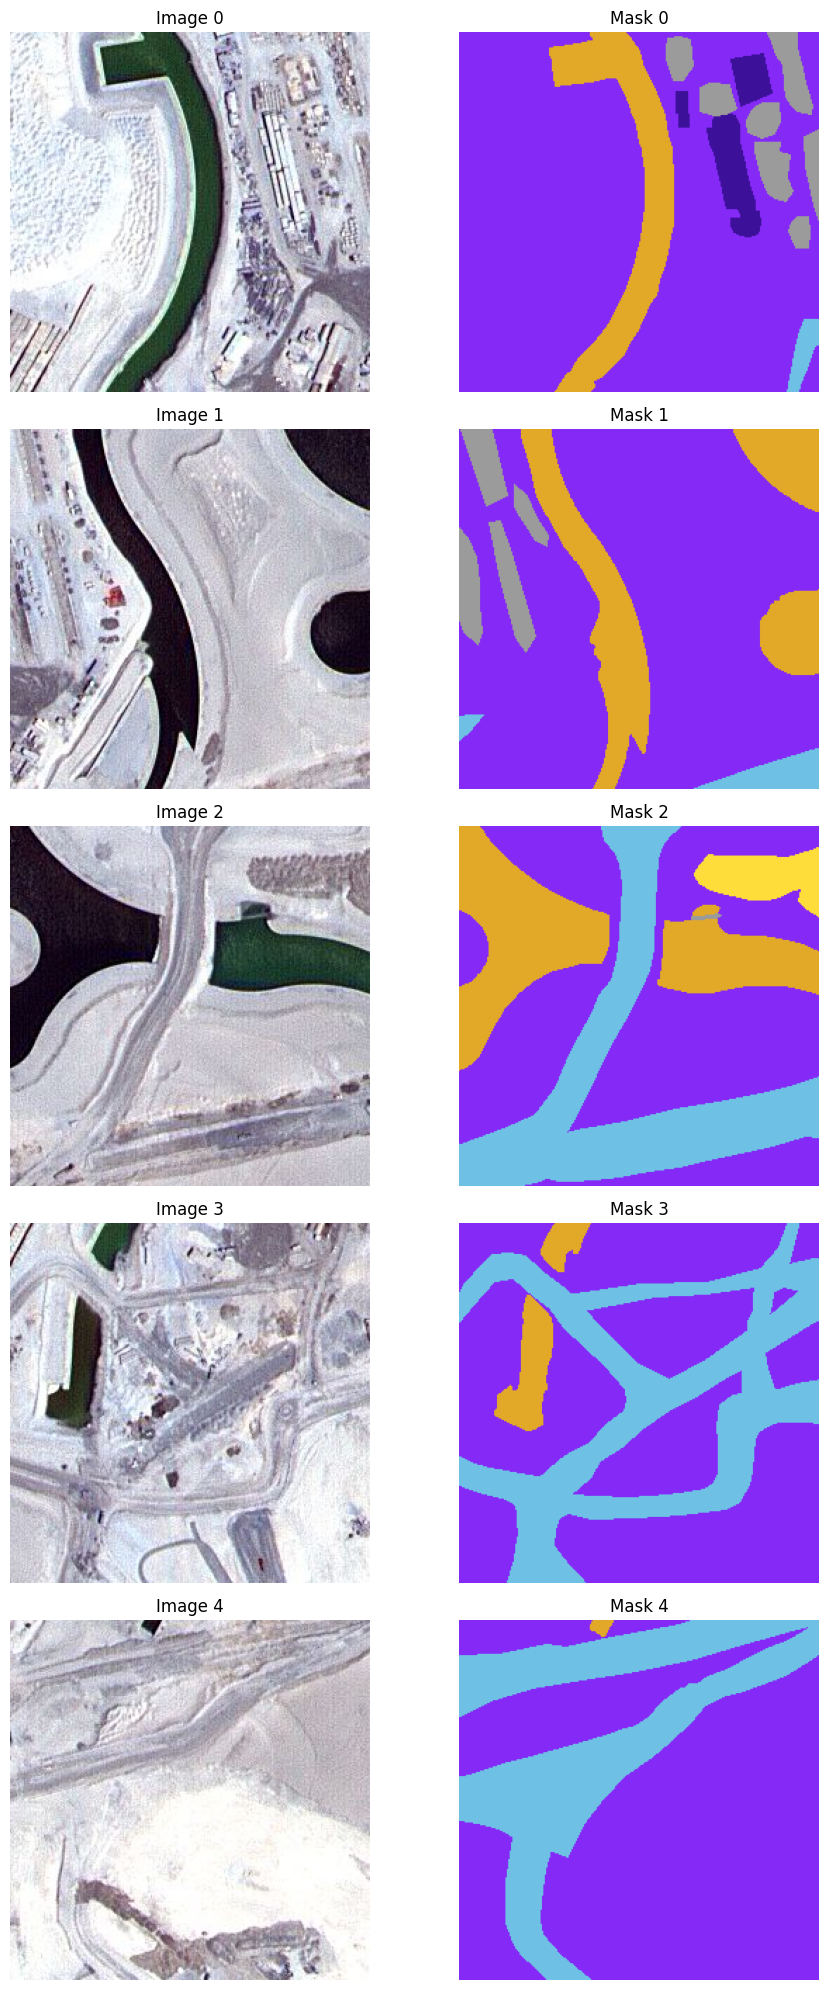

In [10]:
# Visualisation 5 patches
fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):
    # Image
    axes[i, 0].imshow(image_dataset[i])
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f'Image {i}')

    # Masque
    axes[i, 1].imshow(mask_dataset[i])
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f'Mask {i}')

plt.tight_layout()
plt.show()

In [11]:
# 1. Lire le fichier jason
with open(f'{dataset_root_folder}/classes.json', 'r', encoding='utf-8') as f:
        data = json.load(f)

# 2. Afficher data
data["classes"]

[{'title': 'Water',
  'shape': 'polygon',
  'color': '#E2A929',
  'geometry_config': {}},
 {'title': 'Land (unpaved area)',
  'shape': 'polygon',
  'color': '#8429F6',
  'geometry_config': {}},
 {'title': 'Road',
  'shape': 'polygon',
  'color': '#6EC1E4',
  'geometry_config': {}},
 {'title': 'Building',
  'shape': 'polygon',
  'color': '#3C1098',
  'geometry_config': {}},
 {'title': 'Vegetation',
  'shape': 'polygon',
  'color': '#FEDD3A',
  'geometry_config': {}},
 {'title': 'Unlabeled',
  'shape': 'polygon',
  'color': '#9B9B9B',
  'geometry_config': {}}]

In [12]:
classe_names=[]
classe_colors =[]

for j in range(6):
 classe_name = data["classes"][j]["title"]
 classe_names.append(classe_name)
 color = data["classes"][j]["color"]
 classe_colors.append(color)

classe_names, classe_colors

(['Water',
  'Land (unpaved area)',
  'Road',
  'Building',
  'Vegetation',
  'Unlabeled'],
 ['#E2A929', '#8429F6', '#6EC1E4', '#3C1098', '#FEDD3A', '#9B9B9B'])

In [13]:
# Convertir hex → RGB pour vérifier les valeurs
def hex_to_rgb(hex_color):

   rgb = []

   for j in range(len(hex_color)):
     hex_color_1 = hex_color[j].lstrip('#')
     rgb.append(tuple(int(hex_color_1[i:i+2], 16) for i in (0, 2, 4)))

   return rgb

class_color_rgb = hex_to_rgb(classe_colors)
class_color_rgb

[(226, 169, 41),
 (132, 41, 246),
 (110, 193, 228),
 (60, 16, 152),
 (254, 221, 58),
 (155, 155, 155)]


    [226, 169, 41],   # Classe 0 - Jaune/Orange    'Water'
    [132, 41, 246],   # Classe 1 - Violet          'Land (unpaved area)'
    [110, 193, 228],  # Classe 2 - Bleu clair      'Road'
    [60, 16, 152],    # Classe 3 - Violet foncé    'Building'
    [254, 221, 58],   # Classe 4 - Jaune vif       'Vegetation'
    [155, 155, 155]   # Classe 5 - Gris            'Unlabeled'

In [14]:
def rgb_to_label(label, class_color_rgb):
  label_segment = np.zeros(label.shape, dtype=np.uint8)
  label_segment[np.all(label == class_color_rgb[0], axis=-1)] = 0
  label_segment[np.all(label == class_color_rgb[1], axis=-1)] = 1
  label_segment[np.all(label == class_color_rgb[2], axis=-1)] = 2
  label_segment[np.all(label == class_color_rgb[3], axis=-1)] = 3
  label_segment[np.all(label == class_color_rgb[4], axis=-1)] = 4
  label_segment[np.all(label == class_color_rgb[5], axis=-1)] = 5
  #print(label_segment)
  label_segment = label_segment[:,:,0]
  #print(label_segment)
  return label_segment

In [15]:
labels = []
for i in range(mask_dataset.shape[0]):
  label = rgb_to_label(mask_dataset[i], class_color_rgb)
  labels.append(label)

In [16]:
total_classes = len(np.unique(labels))
total_classes

6

In [17]:
labels = np.array(labels)
labels.shape

(945, 256, 256)

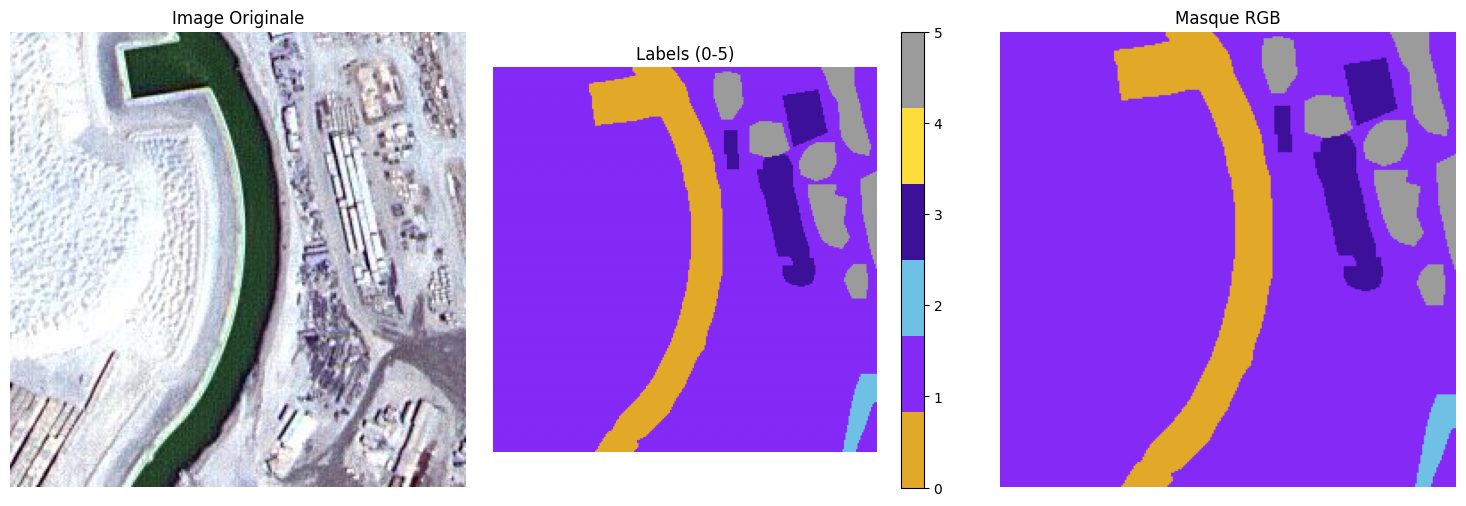

In [18]:


# verfi si labels et masks sont pareil

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Image originale
axes[0].imshow(image_dataset[0])
axes[0].set_title('Image Originale')
axes[0].axis('off')

# 2. Labels (converti) avec couleurs personnalisées
colors_normalized = np.array(class_color_rgb) / 255.0
custom_cmap = ListedColormap(colors_normalized)

im1 = axes[1].imshow(labels[0], cmap=custom_cmap, vmin=0, vmax=5)
axes[1].set_title(f'Labels (0-{total_classes-1})')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], ticks=range(total_classes))

# 3. Masque RGB original
axes[2].imshow(mask_dataset[0])
axes[2].set_title('Masque RGB')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [41]:
#labels = np.expand_dims(labels, axis=3)
#labels.shape

(945, 256, 256, 1)

In [19]:
labels_categorical_dataset_1 = labels #to_categorical(labels, num_classes=total_classes)
labels_categorical_dataset_1

array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 5, 5, ..., 0, 0, 0],
        [1, 5, 5, ..., 0, 0, 0],
        [1, 1, 5, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 2, 2, 2],
        [1, 1, 1, ..., 2, 2, 2],
        [1, 1, 1, ..., 2, 2, 2]],

       [[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        ...,
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 

In [20]:
# normaliser data
master_training_dataset = image_dataset [:15] / 255

labels_categorical_dataset = labels_categorical_dataset_1 [:15]

pris 30 image parmi 1302 unabl locate !!! et validation?,

In [21]:
# 1. D'abord séparer Train (70%) et Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    master_training_dataset,
    labels_categorical_dataset,
    test_size=0.30,  # 30% pour val + test
    random_state=42
)

# 2. Puis séparer Temp en Val (50%) et Test (50%)
# → Val = 15%, Test = 15% du total
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,  # 50% de 30% = 15% du total
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (10, 256, 256, 3)
y_train shape: (10, 256, 256)
X_val shape:   (2, 256, 256, 3)
y_val shape:   (2, 256, 256)
X_test shape:  (3, 256, 256, 3)
y_test shape:  (3, 256, 256)


In [22]:
image_height = X_train.shape[1]
image_width = X_train.shape[2]
image_channels = X_train.shape[3]
print(image_height)
print(image_width)
print(image_channels)

256
256
3


# U-Net

In [72]:
# 1ere methode : U-Net avec 2 bloc

def unet_2blocks(input_size=(image_patch_size, image_patch_size, 3), num_classes=6):
    """
    U-Net avec 2 blocs de convolution (version simplifiée) - avec Conv2DTranspose

    Args:
        input_size: Taille de l'image d'entrée (H, W, C)
        num_classes: Nombre de classes de segmentation

    Returns:
        Modèle U-Net
    """
    inputs = layers.Input(input_size)

    # ============ ENCODEUR (Downsampling) ============

    # Bloc 1
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Dropout(0.1)(conv1)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    # Bloc 2
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Dropout(0.1)(conv2)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # ============ BOTTLENECK ============
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Dropout(0.1)(conv3)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)

    # ============ DECODEUR (Upsampling avec Conv2DTranspose) ============

    # Bloc 2 (upsampling)
    up2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv3)
    merge2 = layers.concatenate([conv2, up2], axis=-1)
    conv4 = layers.Conv2D(128, 3, activation='relu', padding='same')(merge2)
    conv4 = layers.Dropout(0.1)(conv4)
    conv4 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv4)

    # Bloc 1 (upsampling)
    up1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv4)
    merge1 = layers.concatenate([conv1, up1], axis=-1)
    conv5 = layers.Conv2D(64, 3, activation='relu', padding='same')(merge1)
    conv5 = layers.Dropout(0.1)(conv5)
    conv5 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv5)

    # ============ SORTIE ============
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(conv5)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Créer le modèle
# model = unet_2blocks(input_size=(image_patch_size, image_patch_size, 3), num_classes=total_classes)
# model.summary()

In [23]:
# 2éme methode : U-Net avec 2 bloc

def unet_2blocks(input_size=(image_patch_size, image_patch_size, 3), num_classes=6):
    """
    U-Net avec 2 blocs de convolution (version simplifiée)

    Args:
        input_size: Taille de l'image d'entrée (H, W, C)
        num_classes: Nombre de classes de segmentation

    Returns:
        Modèle U-Net
    """
    inputs = layers.Input(input_size)

    # ============ ENCODEUR (Downsampling) ============

    # Bloc 1
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Dropout(0.1)(conv1)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    # Bloc 2
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Dropout(0.1)(conv2)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # ============ BOTTLENECK ============
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Dropout(0.1)(conv3)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)

    # ============ DECODEUR (Upsampling) ============

    # Bloc 2 (upsampling)
    up2 = layers.UpSampling2D(size=(2, 2))(conv3)
    up2 = layers.Conv2D(128, 2, activation='relu', padding='same')(up2)
    merge2 = layers.concatenate([conv2, up2], axis=-1)
    conv4 = layers.Conv2D(128, 3, activation='relu', padding='same')(merge2)
    conv4 = layers.Dropout(0.1)(conv4)
    conv4 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv4)

    # Bloc 1 (upsampling)
    up1 = layers.UpSampling2D(size=(2, 2))(conv4)
    up1 = layers.Conv2D(64, 2, activation='relu', padding='same')(up1)
    merge1 = layers.concatenate([conv1, up1], axis=-1)
    conv5 = layers.Conv2D(64, 3, activation='relu', padding='same')(merge1)
    conv5 = layers.Dropout(0.1)(conv5)
    conv5 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv5)

    # ============ SORTIE ============
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(conv5)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Créer le modèle
model = unet_2blocks(input_size=(image_patch_size, image_patch_size, 3), num_classes=total_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ dropout_2[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    131,200 │ up_sampling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_7[0][0]  

 Total params: 1,863,174 (7.11 MB)

 Trainable params: 1,863,174 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

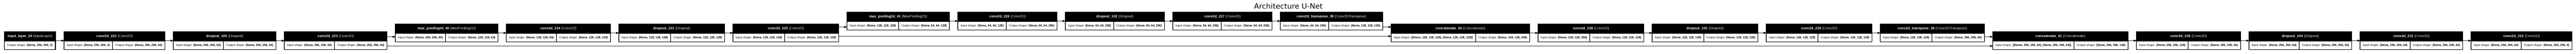

In [101]:
from tensorflow.keras.utils import plot_model
import matplotlib.image as mpimg


# Sauvegarder temporairement (nécessaire pour plot_model)
temp_file = '/content/unet_temp.png'
plot_model(
    model,
    to_file=temp_file,
    show_shapes=True,
    show_layer_names=True,
    dpi=100,
    expand_nested=True
)

# Afficher
img = mpimg.imread(temp_file)
plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis('off')
plt.title('Architecture U-Net', fontsize=16)
plt.show()

# Supprimer le fichier temporaire
os.remove(temp_file)

In [24]:
# Compiler le modèle
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_unet_model_1.h5',
        monitor='val_loss',
        save_best_only=True
    )
]

# Entraînement
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48s/step - accuracy: 0.0958 - loss: 1.8252

1/1 ━━━━━━━━━━━━━━━━━━━━ 50s 50s/step - accuracy: 0.0958 - loss: 1.8252 - val_accuracy: 0.7568 - val_loss: 1.6380 - learning_rate: 0.0010


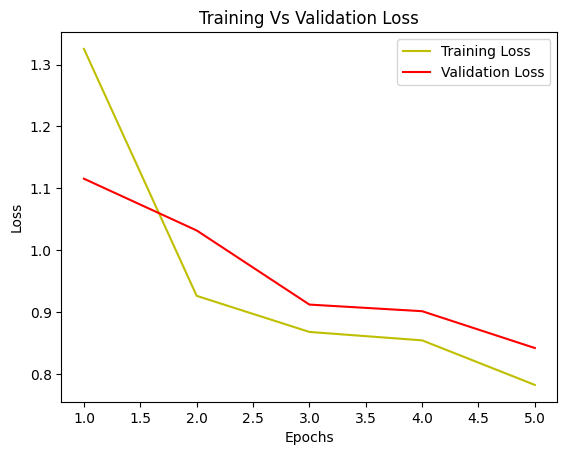

In [41]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label="Training Loss")
plt.plot(epochs, val_loss, 'r', label="Validation Loss")
plt.title("Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [42]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [43]:
len(y_pred)

3

In [44]:
y_pred.shape

(3, 256, 256, 6)

In [61]:
y_pred_argmax = np.argmax(y_pred, axis=3)
y_pred_argmax.shape , y_test.shape

((3, 256, 256), (3, 256, 256))

In [49]:
#y_test_argmax = np.argmax(y_test, axis=3)
#y_test_argmax = y_test

# Vision Transformer (ViT)

## Comparing prediction results
-  using test images using mask images and predicted result images..

In [70]:
test_image_number = 0

test_image = X_test[test_image_number]
ground_truth_image_mask = y_test[test_image_number]
predicted_image  = y_pred_argmax[test_image_number]

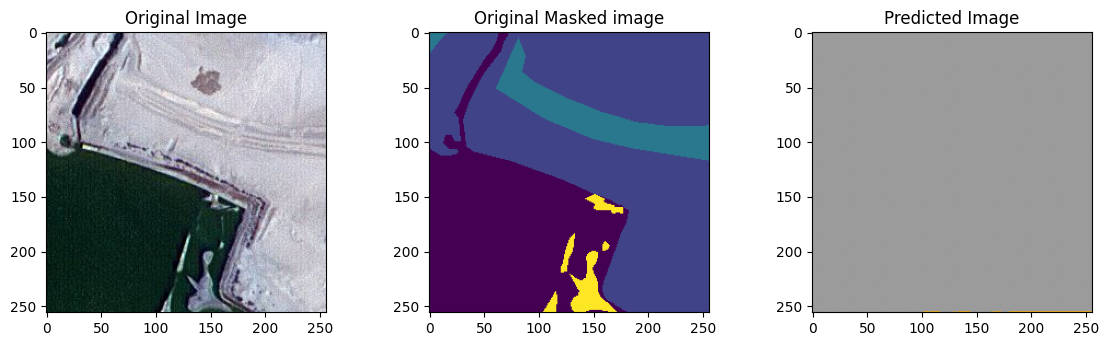

In [71]:
plt.figure(figsize=(14,8))
plt.subplot(231)
plt.title("Original Image")
plt.imshow(test_image)
plt.subplot(232)
plt.title("Original Masked image")
plt.imshow(ground_truth_image_mask)
plt.subplot(233)
plt.title("Predicted Image")
colors_normalized = np.array(class_color_rgb) / 255.0
custom_cmap = ListedColormap(colors_normalized)
plt.imshow(predicted_image, cmap=custom_cmap)
